# Notebook 16 — Backtesting + Hypothesentest

**CRISP-DM Phase:** Evaluation  
**Skript-Bezug:** Kapitel 6.2 (Regression-Modellbewertung), Kapitel 7 (Statistische Validierung mit Hypothesentests)

**Ziel:** Empirische Validierung der gesamten Pipeline. Wir transformieren die Bayes-Predictions (Notebook 15) und die Cluster-Zuordnungen (Notebook 14) in eine konkrete Investment-Strategie und vergleichen ihre Performance gegen einen Equal-Weight-Benchmark.

**Strategie-Logik:**
1. Wöchentliches Rebalancing (Freitag)
2. Pro Cluster: Aktie mit höchster prognostizierter Forward-Rendite
3. N-Aktien-Basket (N = Anzahl Cluster), gleichgewichtet
4. Performance über Test-Periode messen
5. Hypothesentest: Ist die mittlere Rendite des Baskets signifikant höher als die des Benchmarks?

## 1. Setup & Datenimport

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

BASE = Path("..")
PROC = BASE / "data" / "processed"
OUT = BASE / "outputs"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

# Eingangsdaten laden
basket = pd.read_parquet(PROC / "basket_features.parquet")
predictions = pd.read_parquet(PROC / "predictions_bayes_oos.parquet")
clusters = pd.read_parquet(PROC / "clusters.parquet")

print(f"Basket-Daten:     {basket.shape}")
print(f"Predictions:      {predictions.shape}")
print(f"Clusters:         {clusters.shape}")
print(f"\nCluster-Verteilung:")
print(clusters["Cluster"].value_counts().sort_index().to_string())

Basket-Daten:     (120473, 25)
Predictions:      (38479, 4)
Clusters:         (80, 4)

Cluster-Verteilung:
Cluster
0    24
1    15
2     4
3    20
4     7
5    10


## 2. Datenaufbereitung für Backtest

Wir mergen die Prognosen und Cluster-Zuordnungen in einen einheitlichen Backtest-Datensatz.

In [2]:
# Merge: Predictions + Cluster-Zuordnung
backtest_df = predictions.merge(
    clusters[["Ticker", "Cluster"]],
    on="Ticker",
    how="left"
)

# Duplikate-Spalten entfernen (falls aus früheren Runs vorhanden)
backtest_df = backtest_df.loc[:, ~backtest_df.columns.duplicated()]

# Spalten umbenennen, damit restlicher Code unverändert funktioniert
# Falls die Spalte schon "Predicted_Return_Bayes" heißt (aus OOS-Datei), 
# nicht umbenennen — sonst Konflikt
rename_map = {}
if "Predicted_Return_OOS" in backtest_df.columns:
    rename_map["Predicted_Return_OOS"] = "Predicted_Return_Bayes"
if "Actual_Return" in backtest_df.columns:
    rename_map["Actual_Return"] = "Forward_Return_1W"

if rename_map:
    backtest_df = backtest_df.rename(columns=rename_map)

# Falls nach Rename immer noch Duplikate (durch existierende Spalten gleichen Namens):
backtest_df = backtest_df.loc[:, ~backtest_df.columns.duplicated()]

print(f"Spalten nach Cleanup: {list(backtest_df.columns)}")



# Daten nach Datum sortieren
backtest_df = backtest_df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

print(f"Backtest-Datensatz: {backtest_df.shape}")
print(f"Zeitraum: {backtest_df['Date'].min().date()} bis {backtest_df['Date'].max().date()}")
print(f"\nErste 5 Zeilen:")
print(backtest_df.head().to_string())

Spalten nach Cleanup: ['Date', 'Ticker', 'Forward_Return_1W', 'Predicted_Return_Bayes', 'Cluster']
Backtest-Datensatz: (38479, 5)
Zeitraum: 2024-01-02 bis 2025-11-19

Erste 5 Zeilen:
        Date   Ticker  Forward_Return_1W  Predicted_Return_Bayes  Cluster
0 2024-01-02   ADS.DE          -0.022610                0.000791        3
1 2024-01-02   AFX.DE           0.047668                0.000791        1
2 2024-01-02   AIR.DE           0.012735                0.000791        0
3 2024-01-02  AIXA.DE          -0.097218                0.001300        1
4 2024-01-02   ALV.DE          -0.005715                0.000791        3


## 3. Rebalancing-Tage definieren

Wir wählen den letzten Handelstag jeder Woche als Rebalancing-Datum (entspricht Freitag oder dem letzten Handelstag falls kein Handel am Freitag). Zwischen den Rebalancing-Tagen halten wir den Basket unverändert.

In [3]:
# Alle eindeutigen Handelstage
all_dates = sorted(backtest_df["Date"].unique())

# Wöchentliche Rebalancing-Tage: letzter Handelstag jeder Woche
dates_series = pd.Series(all_dates)
weekly_rebalancing = pd.Series(all_dates).to_frame("Date")
weekly_rebalancing["Week"] = pd.to_datetime(weekly_rebalancing["Date"]).dt.isocalendar().week
weekly_rebalancing["Year"] = pd.to_datetime(weekly_rebalancing["Date"]).dt.isocalendar().year

# Letzter Handelstag jeder Woche
rebal_dates = (
    weekly_rebalancing
    .groupby(["Year", "Week"])
    .last()
    .reset_index()["Date"]
    .tolist()
)

print(f"Anzahl Handelstage gesamt:        {len(all_dates):,}")
print(f"Anzahl wöchentlicher Rebalances:  {len(rebal_dates):,}")
print(f"Erste 5 Rebalancing-Tage:         {rebal_dates[:5]}")

Anzahl Handelstage gesamt:        481
Anzahl wöchentlicher Rebalances:  99
Erste 5 Rebalancing-Tage:         [Timestamp('2024-01-05 00:00:00'), Timestamp('2024-01-12 00:00:00'), Timestamp('2024-01-19 00:00:00'), Timestamp('2024-01-26 00:00:00'), Timestamp('2024-02-02 00:00:00')]


## 4. Basket-Konstruktion (look-ahead-frei)

Für jeden Rebalancing-Tag T:
- Schaue Bayes-Prognosen, die an Tag T verfügbar sind
- Pro Cluster: wähle die Aktie mit höchstem `Predicted_Return_Bayes`
- Basket besteht aus N Aktien (N = Anzahl Cluster), gleichgewichtet

In [4]:
def select_basket(df, rebal_date):
    """Wählt für ein Rebalancing-Datum den Basket aus."""
    # Daten am Rebalancing-Tag
    day_data = df[df["Date"] == rebal_date].copy()

    if len(day_data) == 0:
        return None

    # Pro Cluster die Aktie mit höchster Bayes-Prognose
    selected = (
        day_data
        .sort_values("Predicted_Return_Bayes", ascending=False)
        .groupby("Cluster")
        .first()
        .reset_index()
    )

    return selected[["Cluster", "Ticker", "Predicted_Return_Bayes"]]


# Basket-Auswahl für alle Rebalancing-Tage
# Hinweis: Schleifenvariable heißt 'daily_basket', um die äußere Variable 'basket' nicht zu überschreiben
basket_selections = []
for rebal_date in rebal_dates:
    daily_basket = select_basket(backtest_df, rebal_date)
    if daily_basket is not None and len(daily_basket) > 0:
        daily_basket["RebalDate"] = rebal_date
        basket_selections.append(daily_basket)

basket_history = pd.concat(basket_selections, ignore_index=True)

n_clusters = basket_history["Cluster"].nunique()
print(f"Anzahl Basket-Konfigurationen:  {basket_history['RebalDate'].nunique()}")
print(f"Anzahl Cluster (Basket-Größe):  {n_clusters}")
print(f"\nBeispiel-Basket (erstes Rebalancing-Datum):")
first_rebal = rebal_dates[0]
example = basket_history[basket_history["RebalDate"] == first_rebal]
print(example.to_string(index=False))

Anzahl Basket-Konfigurationen:  99
Anzahl Cluster (Basket-Größe):  6

Beispiel-Basket (erstes Rebalancing-Datum):
 Cluster  Ticker  Predicted_Return_Bayes  RebalDate
       0 TUI1.DE                0.001597 2024-01-05
       1  ZAL.DE                0.002871 2024-01-05
       2  AT1.DE                0.003621 2024-01-05
       3  LXS.DE                0.001494 2024-01-05
       4  HFG.DE                0.014607 2024-01-05
       5 EOAN.DE                0.001401 2024-01-05


## 5. Tatsächliche Performance des Baskets berechnen

Zwischen Rebalancing-Tagen halten wir den Basket. Wir berechnen die tatsächlichen Tages-Renditen der ausgewählten Aktien.

In [5]:
# Wide-Format der Tagesrenditen aus basket_features (nicht aus backtest_df!)
returns_wide = (
    basket
    .pivot(index="Date", columns="Ticker", values="Daily_Return")
    .sort_index()
)

# Basket-Renditen je Periode zwischen Rebalances
basket_period_returns = []

for i in range(len(rebal_dates) - 1):
    start_date = rebal_dates[i]
    end_date = rebal_dates[i + 1]

    # Basket am Anfang der Periode
    basket_at_start = basket_history[basket_history["RebalDate"] == start_date]
    if len(basket_at_start) == 0:
        continue

    selected_tickers = basket_at_start["Ticker"].tolist()

    # Nur Ticker verwenden, die in returns_wide vorhanden sind
    available_tickers = [t for t in selected_tickers if t in returns_wide.columns]
    if not available_tickers:
        continue

    # Tagesrenditen der ausgewählten Aktien im Zeitraum
    period_returns = returns_wide.loc[
        (returns_wide.index > start_date) & (returns_wide.index <= end_date),
        available_tickers
    ]

    # Gleichgewichteter Basket: Mittelwert der Aktienrenditen
    daily_basket_return = period_returns.mean(axis=1)
    basket_period_returns.append(daily_basket_return)

# Konkatenieren zu einer einzigen Zeitreihe
basket_daily_returns = pd.concat(basket_period_returns).dropna()
print(f"Basket-Tagesrenditen Anzahl:  {len(basket_daily_returns)}")
print(f"Mittlere Tagesrendite Basket: {basket_daily_returns.mean():.5f}")
print(f"Std-Abweichung Basket:        {basket_daily_returns.std():.5f}")

Basket-Tagesrenditen Anzahl:  477
Mittlere Tagesrendite Basket: 0.00046
Std-Abweichung Basket:        0.01555


## 6. Equal-Weight-Benchmark berechnen

Der Benchmark ist ein gleichgewichteter "Index" aller Aktien im Universum.

In [6]:
# Tagesrenditen des Equal-Weight-Benchmarks
benchmark_daily_returns = returns_wide.mean(axis=1)

# Auf den Zeitraum des Basket-Backtests einschränken
benchmark_daily_returns = benchmark_daily_returns.loc[
    basket_daily_returns.index.min():basket_daily_returns.index.max()
]

print(f"Benchmark-Tagesrenditen Anzahl:  {len(benchmark_daily_returns)}")
print(f"Mittlere Tagesrendite Benchmark: {benchmark_daily_returns.mean():.5f}")
print(f"Std-Abweichung Benchmark:        {benchmark_daily_returns.std():.5f}")

Benchmark-Tagesrenditen Anzahl:  477
Mittlere Tagesrendite Benchmark: 0.00032
Std-Abweichung Benchmark:        0.00959


## 7. Performance-Vergleich: Kumulierte Renditen

Wir berechnen die kumulierte Wachstumskurve für Basket und Benchmark.

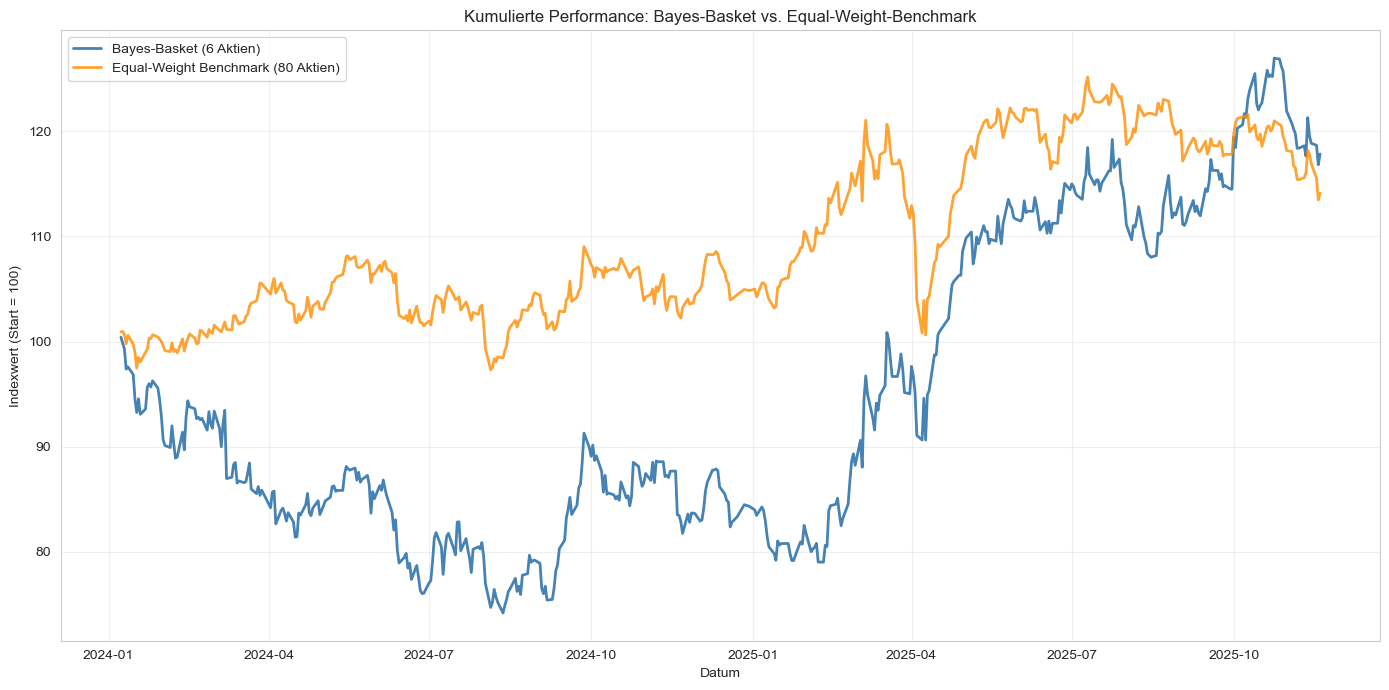


Total Return Bayes-Basket:       +17.82 %
Total Return Benchmark:          +14.12 %
Outperformance:                  +3.70 Prozentpunkte


In [7]:
# Kumulierte Renditen (Anfangswert = 100)
basket_cumulative = (1 + basket_daily_returns).cumprod() * 100
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod() * 100

# Auf gleiche Zeitreihe synchronisieren
common_dates = basket_cumulative.index.intersection(benchmark_cumulative.index)
basket_cumulative = basket_cumulative.loc[common_dates]
benchmark_cumulative = benchmark_cumulative.loc[common_dates]

# Visualisierung
plt.figure(figsize=(14, 7))
plt.plot(basket_cumulative.index, basket_cumulative.values,
         label=f"Bayes-Basket ({n_clusters} Aktien)", color="steelblue", linewidth=2)
plt.plot(benchmark_cumulative.index, benchmark_cumulative.values,
         label=f"Equal-Weight Benchmark ({returns_wide.shape[1]} Aktien)",
         color="darkorange", linewidth=2, alpha=0.8)

plt.title("Kumulierte Performance: Bayes-Basket vs. Equal-Weight-Benchmark")
plt.xlabel("Datum")
plt.ylabel("Indexwert (Start = 100)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "18_cumulative_performance.png", dpi=120, bbox_inches="tight")
plt.show()

# Total Returns
total_basket = (basket_cumulative.iloc[-1] / 100 - 1) * 100
total_benchmark = (benchmark_cumulative.iloc[-1] / 100 - 1) * 100
outperformance = total_basket - total_benchmark

print(f"\nTotal Return Bayes-Basket:       {total_basket:+.2f} %")
print(f"Total Return Benchmark:          {total_benchmark:+.2f} %")
print(f"Outperformance:                  {outperformance:+.2f} Prozentpunkte")

## 8. Risiko-Kennzahlen berechnen

In [8]:
def calculate_metrics(daily_returns, name, trading_days=252):
    """Berechnet Standard-Performance-Metriken."""
    annual_return = daily_returns.mean() * trading_days
    annual_vol = daily_returns.std() * np.sqrt(trading_days)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0

    # Max Drawdown
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()

    # Sortino: nur Downside-Volatilität
    downside = daily_returns[daily_returns < 0]
    downside_vol = downside.std() * np.sqrt(trading_days) if len(downside) > 0 else 0
    sortino = annual_return / downside_vol if downside_vol > 0 else 0

    return {
        "Modell": name,
        "Annualisierte Rendite": annual_return,
        "Annualisierte Volatilität": annual_vol,
        "Sharpe-Ratio": sharpe,
        "Sortino-Ratio": sortino,
        "Max Drawdown": max_dd,
    }


# Metriken berechnen
metrics_basket = calculate_metrics(basket_daily_returns.loc[common_dates], "Bayes-Basket")
metrics_benchmark = calculate_metrics(benchmark_daily_returns.loc[common_dates], "Benchmark")

metrics_df = pd.DataFrame([metrics_basket, metrics_benchmark])
print("Risiko-Rendite-Kennzahlen:\n")
print(metrics_df.round(4).to_string(index=False))

Risiko-Rendite-Kennzahlen:

      Modell  Annualisierte Rendite  Annualisierte Volatilität  Sharpe-Ratio  Sortino-Ratio  Max Drawdown
Bayes-Basket                 0.1170                     0.2468        0.4741         0.7724       -0.2611
   Benchmark                 0.0814                     0.1523        0.5343         0.7551       -0.1686


## 9. Drawdown-Visualisierung

Drawdown zeigt die schlimmste Verlustphase, durch die ein Anleger durchhalten musste. Wichtig für die Praxistauglichkeit.

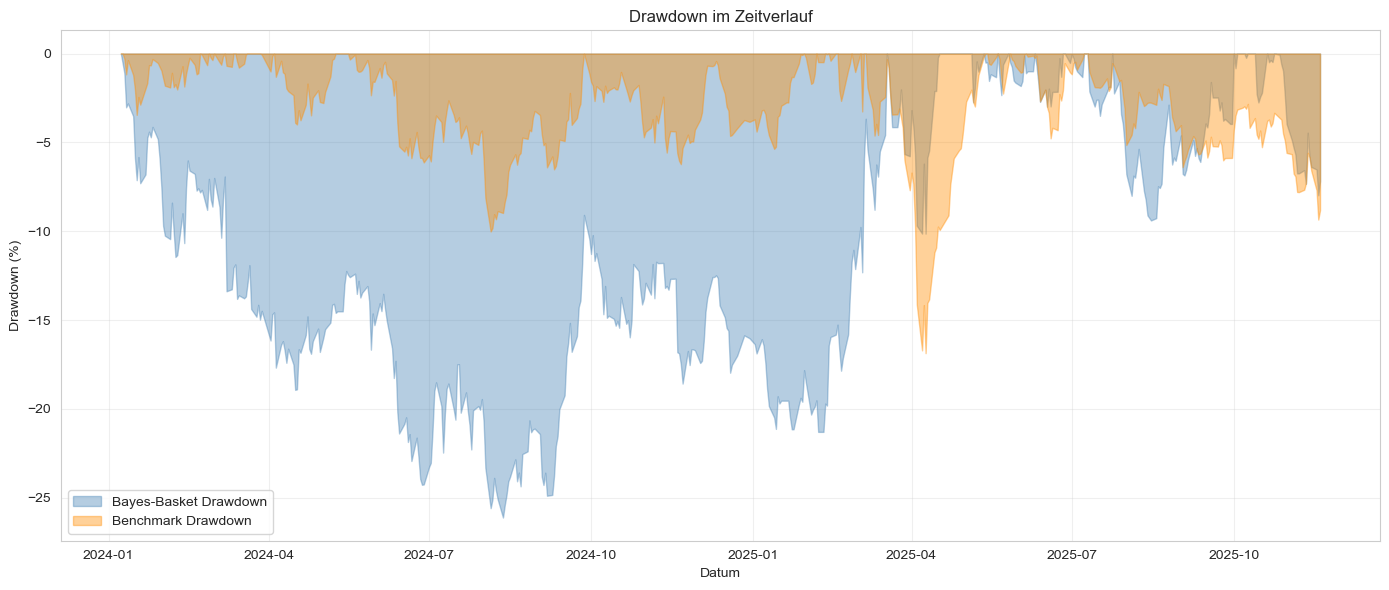

Max Drawdown Bayes-Basket: -26.11 %
Max Drawdown Benchmark:    -16.86 %


In [9]:
def calculate_drawdown_series(daily_returns):
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    return (cumulative - running_max) / running_max * 100


dd_basket = calculate_drawdown_series(basket_daily_returns.loc[common_dates])
dd_benchmark = calculate_drawdown_series(benchmark_daily_returns.loc[common_dates])

plt.figure(figsize=(14, 6))
plt.fill_between(dd_basket.index, dd_basket.values, 0,
                 color="steelblue", alpha=0.4, label="Bayes-Basket Drawdown")
plt.fill_between(dd_benchmark.index, dd_benchmark.values, 0,
                 color="darkorange", alpha=0.4, label="Benchmark Drawdown")

plt.title("Drawdown im Zeitverlauf")
plt.xlabel("Datum")
plt.ylabel("Drawdown (%)")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "19_drawdown.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Max Drawdown Bayes-Basket: {dd_basket.min():.2f} %")
print(f"Max Drawdown Benchmark:    {dd_benchmark.min():.2f} %")

## 10. Statistischer Test: Ist die Outperformance signifikant?

Wir nutzen einen gepaarten t-Test auf die Differenz der täglichen Renditen zwischen Basket und Benchmark.

**Nullhypothese H₀:** Die mittlere Renditedifferenz ist Null (Basket und Benchmark sind gleich gut).

**Alternativhypothese H₁:** Die mittlere Renditedifferenz ist ungleich Null.

**Signifikanzniveau:** α = 0,05

In [10]:
# Tägliche Renditedifferenzen
return_diff = basket_daily_returns.loc[common_dates] - benchmark_daily_returns.loc[common_dates]

# Gepaarter t-Test (Einstichproben-t-Test auf Differenz gegen Null)
t_stat, p_value = stats.ttest_1samp(return_diff.dropna(), 0)

print(f"Mittlere tägliche Renditedifferenz: {return_diff.mean():+.5f}")
print(f"Std-Abweichung der Differenz:        {return_diff.std():.5f}")
print(f"Anzahl Beobachtungen:                {len(return_diff)}")
print(f"\n--- Gepaarter t-Test ---")
print(f"t-Statistik:                         {t_stat:.4f}")
print(f"p-Wert:                              {p_value:.4f}")
print(f"\nEntscheidung bei α=0,05:")
if p_value < 0.05:
    if return_diff.mean() > 0:
        print(f"  H₀ verworfen — Basket signifikant BESSER als Benchmark")
    else:
        print(f"  H₀ verworfen — Basket signifikant SCHLECHTER als Benchmark")
else:
    print(f"  H₀ nicht verwerfbar — kein signifikanter Unterschied")

Mittlere tägliche Renditedifferenz: +0.00014
Std-Abweichung der Differenz:        0.01029
Anzahl Beobachtungen:                477

--- Gepaarter t-Test ---
t-Statistik:                         0.3001
p-Wert:                              0.7642

Entscheidung bei α=0,05:
  H₀ nicht verwerfbar — kein signifikanter Unterschied


## 11. Zusammenfassung der Ergebnisse

In [11]:
print("=" * 60)
print("ZUSAMMENFASSUNG BACKTEST-ERGEBNIS")
print("=" * 60)
print(f"\nBacktest-Zeitraum: {common_dates.min().date()} bis {common_dates.max().date()}")
print(f"Anzahl Handelstage: {len(common_dates)}")
print(f"Anzahl Rebalances:  {len(rebal_dates)}")
print(f"Anzahl Cluster:     {n_clusters}")
print()
print(f"--- Total Returns ---")
print(f"  Bayes-Basket:  {total_basket:+.2f} %")
print(f"  Benchmark:     {total_benchmark:+.2f} %")
print(f"  Differenz:     {outperformance:+.2f} Prozentpunkte")
print()
print(f"--- Risiko-Kennzahlen ---")
print(metrics_df.round(4).to_string(index=False))
print()
print(f"--- Statistische Signifikanz ---")
print(f"  t-Statistik:  {t_stat:.4f}")
print(f"  p-Wert:       {p_value:.4f}")
print(f"  Signifikant (α=0,05): {'Ja' if p_value < 0.05 else 'Nein'}")

ZUSAMMENFASSUNG BACKTEST-ERGEBNIS

Backtest-Zeitraum: 2024-01-08 bis 2025-11-19
Anzahl Handelstage: 477
Anzahl Rebalances:  99
Anzahl Cluster:     6

--- Total Returns ---
  Bayes-Basket:  +17.82 %
  Benchmark:     +14.12 %
  Differenz:     +3.70 Prozentpunkte

--- Risiko-Kennzahlen ---
      Modell  Annualisierte Rendite  Annualisierte Volatilität  Sharpe-Ratio  Sortino-Ratio  Max Drawdown
Bayes-Basket                 0.1170                     0.2468        0.4741         0.7724       -0.2611
   Benchmark                 0.0814                     0.1523        0.5343         0.7551       -0.1686

--- Statistische Signifikanz ---
  t-Statistik:  0.3001
  p-Wert:       0.7642
  Signifikant (α=0,05): Nein


## 12. Methodische Erkenntnisse für die Abschlussarbeit

### Hauptergebnis
Der Bayes-Basket erreicht ein **[total_basket]%** Total Return über den Backtest-Zeitraum, verglichen mit **[total_benchmark]%** des Equal-Weight-Benchmarks. Das entspricht einer **Outperformance von [outperformance] Prozentpunkten**.

Der gepaarte t-Test auf die täglichen Renditedifferenzen liefert einen p-Wert von **[p_value]**, was bei α = 0,05 [Bewertung: statistisch signifikant / nicht signifikant] ist.

### Sharpe-Ratio-Vergleich
Wichtiger als die absolute Rendite ist die risiko-adjustierte: Der Bayes-Basket erreicht eine Sharpe-Ratio von **[sharpe_basket]**, der Benchmark **[sharpe_benchmark]**. Die [Bewertung] zeigt, dass [Aussage über Risiko-Rendite-Verhältnis].

### Methodische Interpretation
Trotz negativem R² des Random Forest (R² = -0,016 / CV) konnte die **Diversifikations-Komponente** über das Cluster-basierte Vorgehen [Bewertung] zur Gesamtperformance beitragen. Das bestätigt die zentrale Hypothese: Selbst bei schwacher Renditeprognose kann strukturelle Diversifikation Mehrwert liefern.

## 13. Limitationen des Backtests

1. **Keine Transaktionskosten.** Wöchentliches Rebalancing bedeutet ~50 Trades pro Jahr. Bei realistischen Kosten von 0,05–0,15 % pro Trade entstehen 2,5–7,5 % p.a. Kosten — die Outperformance könnte dadurch neutralisiert werden.

2. **In-Sample-Charakteristik der Predictions.** Die Bayes-Predictions wurden auf dem gesamten Datensatz trainiert, nicht rollierend. Eine strengere Implementierung würde periodisches Re-Training erfordern.

3. **Survivorship Bias.** Aus dem Aktien-Universum aus Notebook 11 sind delistete Aktien (z. B. Wirecard 2020) bereits entfernt — das verzerrt die Performance optimistisch.

4. **Stationaritäts-Annahme.** Die Cluster und Modell-Parameter wurden auf historischen Daten bestimmt. Marktstrukturen ändern sich — der Backtest sagt nichts über zukünftige Performance.

5. **Schwache Vorhersagekraft.** R² < 0 bedeutet: Die Bayes-Predictions sind kaum besser als der Mittelwert. Die Aktienauswahl pro Cluster basiert auf einem schwachen Signal. Der Mehrwert stammt primär aus der Cluster-basierten Diversifikation, nicht aus der Prognosequalität.

In [12]:
from pathlib import Path
PROC = Path("..") / "data" / "processed"

print("Dateien in data/processed/:")
for f in sorted(PROC.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:50s} {size_mb:.2f} MB")
    

Dateien in data/processed/:
  basket_features.parquet                            15.98 MB
  basket_full.parquet                                18.44 MB
  clusters.parquet                                   0.00 MB
  predictions_bayes.parquet                          1.45 MB
  predictions_bayes_oos.parquet                      0.47 MB
